# XGBoost

### Importación de librerías.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

### Importación de datos.

In [2]:
df = pd.read_csv('DATOS.csv')
df.head(2)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,booking_status_Canceled
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1.0,0.0,0.0,0.0
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0.0,0.0,1.0,0.0


### Separación de etiqueta.

In [3]:
X_pre = df.drop(columns=['booking_status_Canceled'])
y = df['booking_status_Canceled']

### Variables polinómicas.

In [4]:
poly = PolynomialFeatures( degree=2, interaction_only=False, include_bias=False)
X = poly.fit_transform(X_pre)

### División de datos de prueba y entrenamiento.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

### Definición del modelo.

In [6]:
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=0, n_jobs=-1)

### Rejilla de hiperparámetros.

In [7]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [4, 8],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0.1, 0.3],
    "reg_lambda": [1, 5]
}

### GridSearch y validación cruzada.

In [8]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

### Entrenamiento del modelo.

In [9]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 128 candidates, totalling 640 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0.1, 0.3], 'learning_rate': [0.01, 0.1], 'max_depth': [4, 8], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

### Datos del mejor modelo.

In [10]:
print('Mejor combinación de hiperparámetros')
print(grid_search.best_params_)

Mejor combinación de hiperparámetros
{'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 1.0}


In [11]:
print('Mejor recall en validación cruzada')
print(grid_search.best_score_)

Mejor recall en validación cruzada
0.6539982803095443


### Se captura el mejor modelo.

In [12]:
best_model = grid_search.best_estimator_

### Se predice con los datos de prueba.

In [13]:
y_pred = best_model.predict(X_test)

### Se evalúa la capacidad del modelo con nuevos datos.

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.92      0.90      3709
         1.0       0.76      0.67      0.72      1454

    accuracy                           0.85      5163
   macro avg       0.82      0.80      0.81      5163
weighted avg       0.85      0.85      0.85      5163



### Matriz de confusión.

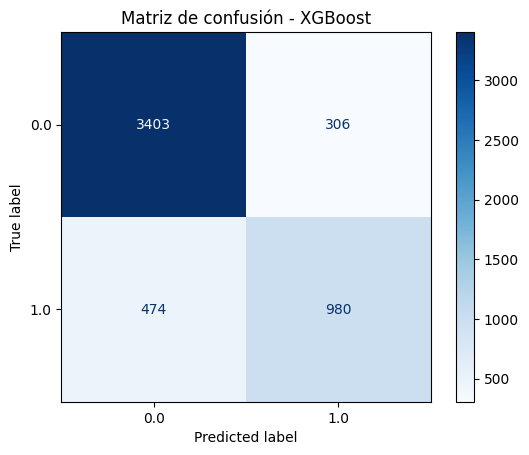

In [15]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)
plt.title("Matriz de confusión - XGBoost")
plt.show()

### Importancia de características.

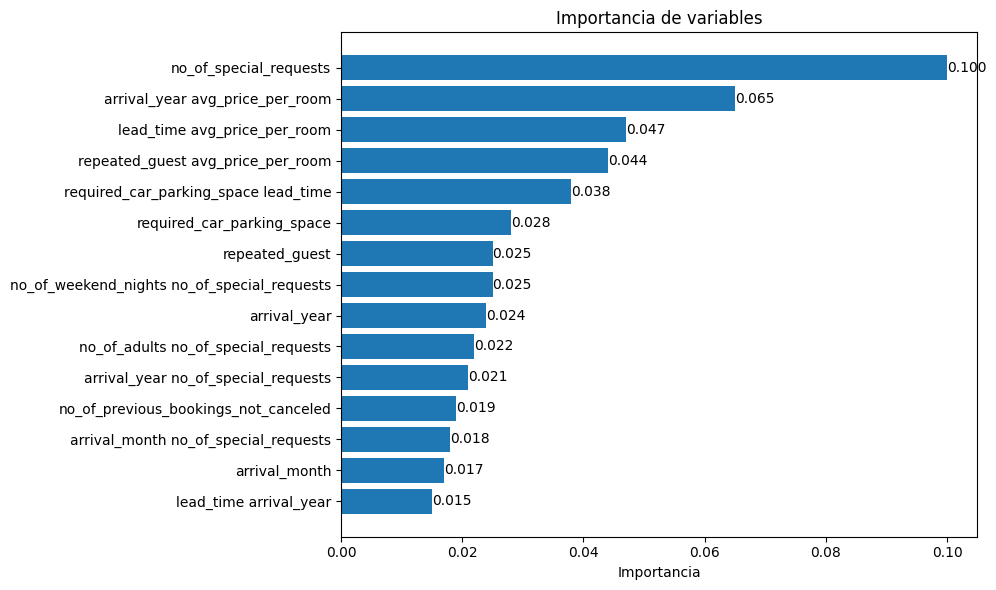

In [21]:
importancias = best_model.feature_importances_
feature_names = poly.get_feature_names_out(X_pre.columns)
df_importancias = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})

df_importancias['Importancia'] = (df_importancias['Importancia'].round(3))
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)
df_importancias = df_importancias.head(15)

plt.figure(figsize=(10, 6))

bars = plt.barh(df_importancias['Variable'][:][::-1], df_importancias['Importancia'][:][::-1])

# Mostrar valor sobre cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.xlabel('Importancia')
plt.title('Importancia de variables')
plt.tight_layout()
plt.show()

### Se evalúa el sobreajuste.

In [19]:
y_pred_train = best_model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96     14833
         1.0       0.93      0.87      0.90      5815

    accuracy                           0.95     20648
   macro avg       0.94      0.92      0.93     20648
weighted avg       0.95      0.95      0.95     20648

